# Single Type Experiment

In [1]:
import warnings;
warnings.filterwarnings('ignore');

from time import sleep
from tqdm.auto import tqdm

import sys
import importlib
import numpy as np
import nbformat
import plotly.express
import plotly.express as px
import pandas as pd
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def offline_opt(budget, size):
    # return [budget / np.sum(size) * size[i] for i in range(len(size))]
    return [budget / np.sum(size) for i in range(len(size))]

In [3]:
def hope_online(budget, size, mean):
    # initialize allocation vector
    allocation = np.zeros(len(size))
    budget_remaining = budget
    for i in range(len(allocation)):
        # allocation[i] = budget_remaining * size[i] / (size[i] + np.sum(mean[i+1:]))
        allocation[i] = budget_remaining / (size[i] + np.sum(mean[i+1:]))
        
        
        budget_remaining -= allocation[i] * size[i]
    return allocation

In [4]:
def hope_full(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    for i in range(len(allocation)):
#         allocation[i] = min(budget_remaining, budget*size[i] / (np.sum(size[0:i+1]) + np.sum(mean[i+1:])))
        allocation[i] = min(budget_remaining / size[i], budget / (np.sum(size[0:i+1]) + np.sum(mean[i+1:])))

        budget_remaining -= allocation[i] * size[i]
    return allocation



In [98]:
def hope_threshold(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
   
    c = 1
    alpha = 0.9
    conf_bnd = c*np.sqrt(np.mean(mean)*len(size)*np.log(len(size)))
    
    thresh = budget / (size[0] + np.sum(mean[1:]) + np.sqrt(np.log(len(size)-1) * (len(size)-1)))

    for i in range(len(allocation)):
       # allocation[i] = min(budget_remaining, thresh * size[i])
        allocation[i] = min(budget_remaining / size[i], thresh)
        budget_remaining -= allocation[i] * size[i]
    return allocation

In [173]:
# Sid's modified version of HOPE with guardrails


# TODO: Add back old hope threshold

def hope_modified(budget, size, mean):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    

    
    c = 0.7

    conf_bnd = c*np.sqrt(np.mean(mean)*(len(size)* np.log(len(size)))) 

    thresh_lower = budget / (size[0] + np.sum(mean[1:]) + conf_bnd)
    thresh_upper = budget / (size[0] + np.sum(mean[1:]) - conf_bnd)

    for i in range(len(allocation)):
        
        if budget_remaining < 0:
            print("Error: Negative Budget")
        

        
        # TODO: add on confidence terms for (T - i) people here
        rem = len(allocation) - (i + 1)
        budget_upper = thresh_upper*(size[i] + np.sum(mean[i+1:])) # + c*np.sqrt(rem * np.log(rem)))
        budget_lower = thresh_lower*(size[i] + np.sum(mean[i+1:])) # + c*np.sqrt(rem * np.log(rem)))

        gam = (budget_remaining - budget_lower) / (budget_upper - budget_lower)
        
#         if budget_remaining >= alpha*budget_upper+ (1-alpha)*budget_lower:
#             allocation[i] = thresh_upper
#         else:
#             allocation[i] = thresh_lower

        if gam >= 0.5:
            allocation[i] = thresh_upper
            # budget_remaining -= allocation[i] * size[i]
        else:
            allocation[i] = thresh_lower
            # budget_remaining -= allocation[i] * size[i]
        
        if allocation[i] * size[i] <= budget_remaining:
            budget_remaining -= allocation[i] * size[i]
            
        else:
            allocation[i] = budget_remaining/size[i]
            budget_remaining = 0

            
    # fix for last agent
    # allocation[-1] = max(min(thresh_upper,budget_remaining / size[-1]),thresh_lower)
    
    return allocation

In [7]:
# def hope_modified(budget, size, mean):
   
#     mean_size = np.mean(mean)
#     allocation = np.zeros(len(size))
#     budget_remaining = budget
#     for i in range(len(allocation)):
#         # allocation[i] = budget_remaining * size[i] / (size[i] + np.sum(mean[i+1:]))
#         allocation[i] = budget_remaining / (size[i] + np.sum(mean[i+1:]) + mean_size*np.log(len(size)))
#         budget_remaining -= allocation[i] * size[i]
#     return allocation




### Test

In [8]:
n = 6
sorted_distribution = np.asarray([np.arange(2) + 1 for x in range(n)])
weights = np.asarray([np.zeros(2)+0.5 for x in range(n)])
mean = [np.dot(weights[i], sorted_distribution[i]) for i in range(n)]

expected_demand = 1.5
budget = n * expected_demand
print(budget)

9.0


In [9]:
print(weights)

[[0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]
 [0.5 0.5]]


In [10]:
print(sorted_distribution)

[[1 2]
 [1 2]
 [1 2]
 [1 2]
 [1 2]
 [1 2]]


In [11]:
size = [2., 1., 1., 1., 2., 1.]

In [12]:
len(size)

6

In [13]:
print(offline_opt(budget, size))

[1.125, 1.125, 1.125, 1.125, 1.125, 1.125]


In [14]:
print(hope_online(budget, size, mean))

[0.94736842 1.01503759 1.10731374 1.24572796 1.06776682 1.60165023]


In [15]:
print(hope_full(budget, size, mean))

[0.94736842 1.         1.05882353 1.125      1.05882353 1.125     ]


In [16]:
print(hope_modified(budget, size, mean))

[0.7384531  0.77656626 0.82398935 0.88559475 0.81403315 0.92440636]


In [17]:
print(hope_threshold(budget, size, mean))

[0.75570436 0.75570436 1.26928953 1.26928953 0.75570436 1.26928953]


### Simulating scaling of $\Delta$

In [18]:
max_n = 100
num_iters = 1000


final_vec = []
for i in np.arange(2, max_n):
    budget = i
    size_one = [1.]
    dist = []
    med = [0., 0.]
    for _ in range(num_iters):
        sizes = np.random.choice(size=i-1, a=[1., 2.], p=[1/2, 1/2])
        # print(size_one, sizes)
        full_size = np.append(size_one[0], sizes)
        # print(len(full_size))
        # print('hi')
        dist.append(1 / np.sum(full_size))
    med[0] = np.median(dist)

    dist = []
    size_one = [2.]
    for _ in range(num_iters):
        sizes = np.random.choice(size=i-1, a=[1., 2.], p=[1/2, 1/2])
        # print(size_one, sizes)
        full_size = np.append(size_one[0], sizes)
        # print(len(full_size))
        # print('hi')
        dist.append(1 / np.sum(full_size))
    med[1] = np.median(dist)

    # print(med)

    dist = []
    for _ in range(num_iters):
        sizes = np.random.choice(size=i, a=[1., 2.], p=[1/2, 1/2])
        dist.append(np.abs( (budget*sizes[0] / np.sum(sizes)) - (budget*sizes[0]*med[int(sizes[0]-1)])))
    final_vec.append(np.mean(dist))

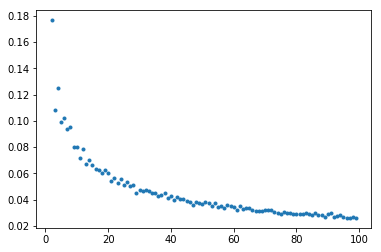

In [19]:
plt.plot(np.arange(2,max_n),final_vec,'.')

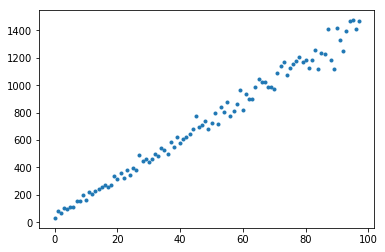

In [20]:
plt.plot([1/(final_vec[i]**2) for i in range(len(final_vec))],'.')

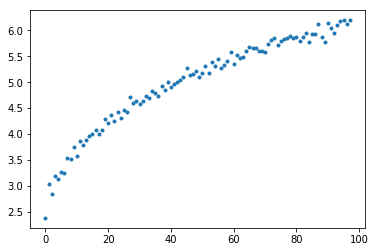

In [21]:
plt.plot([1/(final_vec[i]**(1/2)) for i in range(len(final_vec))],'.')

### Scaling with n

In [22]:
#np.random.choice(size=5, a=[1.,2.], p=[1/2, 1/2])
1+np.random.poisson(size=5,lam = 1.5)

array([2, 2, 2, 2, 2])

In [178]:
data_dict = {'NumGroups':[], 'Norm':[], 'Hope_Online':[], 'Hope_Full':[], 'Hope_Modified':[], 'Hope_Threshold':[]}

num_iterations = 200
max_n = 100

mean_size = 5.

for n in tqdm(np.arange(2,max_n+1)):
    expected_size = np.zeros(n) + mean_size
    budget = n
    
    for i in range(num_iterations):
        
        data_dict['NumGroups'].append(n)
        
        #size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
        size = 1+np.random.poisson(size=n,lam = mean_size-1)
        opt = offline_opt(budget, size)
        hope_on = hope_online(budget, size, expected_size)
        hope_ful = hope_full(budget, size, expected_size)
        hope_mod = hope_modified(budget, size, expected_size)
        hope_thresh = hope_threshold(budget, size, expected_size)
     
        data_dict['Norm'].append('L1')
        data_dict['Hope_Online'].append(np.sum(np.absolute(opt - hope_on)))
        data_dict['Hope_Full'].append(np.sum(np.absolute(opt-hope_ful)))
        data_dict['Hope_Modified'].append(np.sum(np.absolute(opt-hope_mod)))
        data_dict['Hope_Threshold'].append(np.sum(np.absolute(opt-hope_thresh)))

        data_dict['NumGroups'].append(n)
        data_dict['Norm'].append('Linf')
        data_dict['Hope_Online'].append(np.max(np.absolute(opt - hope_on)))
        data_dict['Hope_Full'].append(np.max(np.absolute(opt-hope_ful)))
        data_dict['Hope_Modified'].append(np.max(np.absolute(opt-hope_mod)))
        data_dict['Hope_Threshold'].append(np.max(np.absolute(opt-hope_thresh)))
        
        data_dict['NumGroups'].append(n)
        data_dict['Norm'].append('Waste')
        data_dict['Hope_Online'].append(budget - np.dot(hope_on, size))
        data_dict['Hope_Full'].append(budget - np.dot(hope_ful,size))
        data_dict['Hope_Modified'].append(budget - np.dot(hope_mod, size))
        data_dict['Hope_Threshold'].append(budget - np.dot(hope_thresh, size))
    sleep(0)

  0%|          | 0/99 [00:00<?, ?it/s]

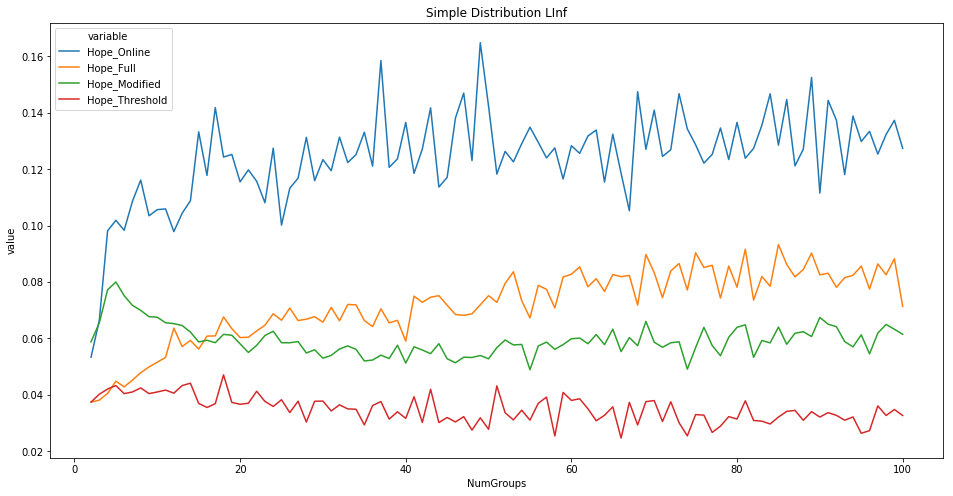

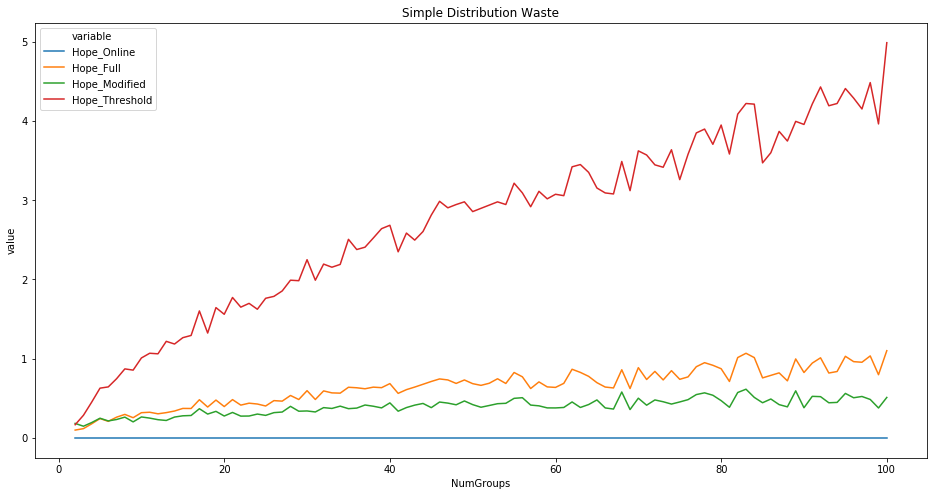

In [179]:
df = pd.DataFrame(data_dict).melt(id_vars=["NumGroups", 'Norm'])
# df.to_csv('scale_with_n.csv')
df.columns


#filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
#plt.figure(figsize=(20,10))
#plt.title('Simple Distribution L1')
#sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution LInf')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'Linf'], ci=None)


filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution Waste')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'Waste'], ci=None)


In [43]:
?sns.lineplot

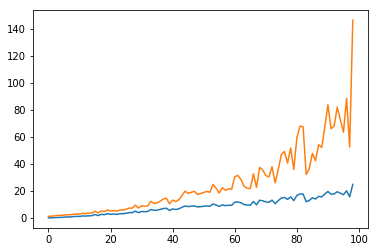

In [180]:
algo = 'Hope_Threshold'
metric = 'Waste'

data = df[(df.Norm == metric) & (df.variable == algo)]
avg = data.groupby(['NumGroups']).mean().to_numpy()
# print(avg)
plt.plot([avg[i]**2 for i in range(len(avg))])
plt.plot([np.exp(avg[i]) for i in range(len(avg))])



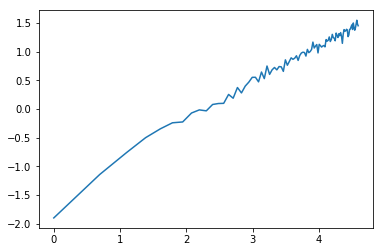

In [172]:
plt.plot(np.log(np.arange(1, max_n)), np.log(avg))

### Group by Group Difference

In [174]:
n = 100
num_iterations = 100

mean_size = 5
expected_size = np.zeros(n) + mean_size
group = np.arange(n)
budget = mean_size*n
group = np.arange(n)

score_hope_online = np.zeros((n,num_iterations))
score_hope_full = np.zeros((n,num_iterations))
score_hope_modified = np.zeros((n, num_iterations))
score_hope_threshold = np.zeros((n, num_iterations))

for i in tqdm(range(num_iterations)):
    size = 1. + np.random.poisson(size=n,lam = mean_size-1)
    #size = np.random.choice(size=n, a=[2.,4.], p=[1/2, 1/2])
    opt = offline_opt(budget, size)
    hope_on = hope_online(budget, size, expected_size)
    hope_ful = hope_full(budget, size, expected_size)
    hope_mod = hope_modified(budget, size, expected_size)
    hope_thresh = hope_threshold(budget, size, expected_size)
    
    # comparing hope_online
    
    score_hope_online[:,i]    = opt - hope_on
    score_hope_full[:,i]      = opt - hope_ful
    score_hope_modified[:,i]  = opt - hope_mod
    score_hope_threshold[:,i] = opt - hope_thresh
    sleep(0)

  0%|          | 0/100 [00:00<?, ?it/s]

In [175]:
size

array([ 6.,  4.,  5.,  5.,  7.,  6.,  5.,  5.,  7.,  5.,  3.,  3.,  4.,
        3.,  9.,  7.,  6.,  3.,  5.,  6.,  6.,  2.,  5.,  2.,  2.,  4.,
       10.,  6.,  5.,  8.,  5.,  4.,  4.,  4.,  4.,  3.,  7.,  5.,  4.,
        8.,  8.,  4.,  5.,  8.,  5.,  5.,  3.,  3.,  5.,  7.,  6.,  2.,
        2.,  5.,  7.,  5.,  4.,  3.,  7.,  8.,  5.,  7.,  8.,  6.,  5.,
        4.,  3.,  4.,  3.,  9.,  5.,  6.,  4.,  6.,  5.,  2.,  7.,  9.,
        9.,  4.,  9.,  4.,  4.,  2.,  4.,  3.,  5.,  7.,  4.,  3.,  3.,
        5.,  7.,  4.,  7.,  2.,  6.,  5.,  6.,  7.])

In [176]:
hope_mod

array([0.91157207, 0.91157207, 0.91157207, 0.91157207, 0.91157207,
       0.91157207, 0.91157207, 0.91157207, 0.91157207, 0.91157207,
       0.91157207, 1.10254308, 1.10254308, 1.10254308, 0.91157207,
       0.91157207, 0.91157207, 1.10254308, 0.91157207, 0.91157207,
       0.91157207, 1.10254308, 1.10254308, 1.10254308, 1.10254308,
       1.10254308, 1.10254308, 1.10254308, 1.10254308, 0.91157207,
       0.91157207, 0.91157207, 1.10254308, 1.10254308, 1.10254308,
       1.10254308, 1.10254308, 1.10254308, 1.10254308, 0.91157207,
       0.91157207, 0.91157207, 0.91157207, 0.91157207, 0.91157207,
       0.91157207, 0.91157207, 1.10254308, 1.10254308, 0.91157207,
       0.91157207, 1.10254308, 1.10254308, 1.10254308, 1.10254308,
       1.10254308, 1.10254308, 1.10254308, 1.10254308, 0.91157207,
       0.91157207, 0.91157207, 0.91157207, 0.91157207, 0.91157207,
       0.91157207, 0.91157207, 0.91157207, 1.10254308, 0.91157207,
       0.91157207, 0.91157207, 0.91157207, 0.91157207, 0.91157

[]

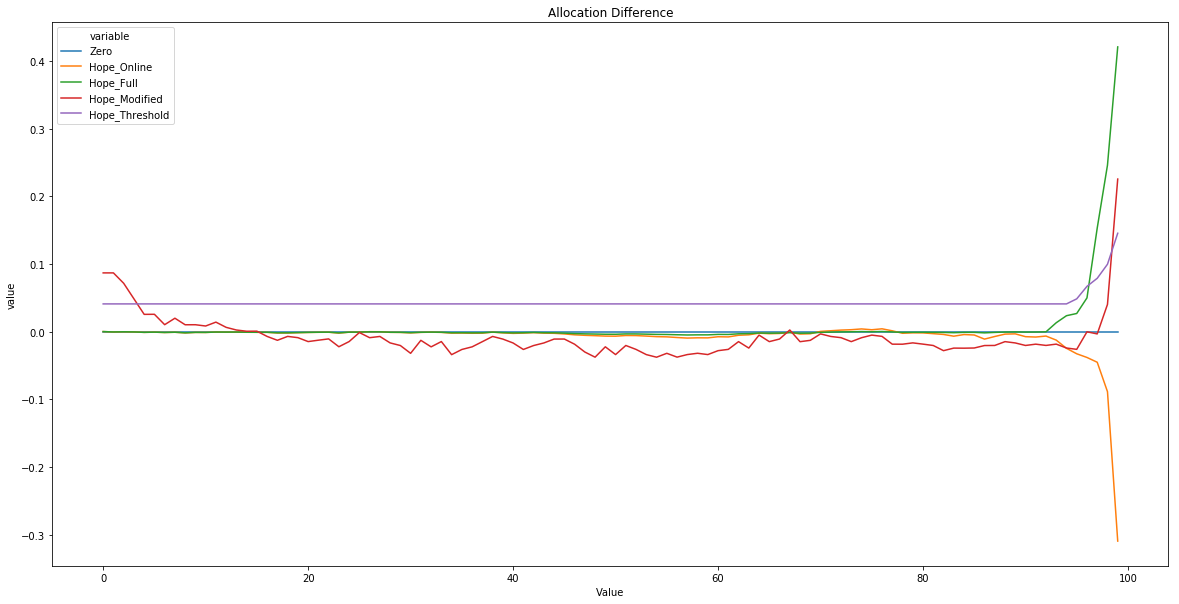

In [177]:
data_dict = {'Agent':group, 'Zero': np.zeros(n), 'Hope_Online': np.average(score_hope_online, axis=1), 'Hope_Full':np.average(score_hope_full, axis=1), 'Hope_Modified':np.average(score_hope_modified, axis=1), 'Hope_Threshold':np.average(score_hope_threshold, axis=1)}
df_uniform = pd.DataFrame(data_dict).melt(id_vars="Agent")

plt.figure(figsize=(20,10))
sns.lineplot(x='Agent', y='value', hue = 'variable', data=df_uniform)
plt.title('Allocation Difference')
plt.xlabel('Value')
plt.plot()